In [2]:
# Install/upgrade the SDK quietly (does nothing if already present)
# %pip -q install --upgrade openai

import os, pathlib, pandas as pd, json, textwrap
from openai import OpenAI
import matplotlib.pyplot as plt


# -------------------------------------------------------------------
# Locate API key: env var ➜ key/openai_key.txt
# -------------------------------------------------------------------
key_path = pathlib.Path("key/openai_key.txt")

if os.getenv("OPENAI_API_KEY") is None and key_path.exists():
    os.environ["OPENAI_API_KEY"] = key_path.read_text().strip()

if not os.getenv("OPENAI_API_KEY"):
    raise ValueError(
        "No API key found.\n"
        "Create key/openai_key.txt (single line) or export OPENAI_API_KEY in your shell."
    )

client = OpenAI()  # SDK reads the key from the env var

In [3]:
# data contains the all papers from the JoF and the top 5 journals except jpe that contain the word stock returns or synonyms in the title
# the sampling period is 20 years (7300 days)
# load csv
df = pd.read_csv(r"C:\Users\jonat\Lasso_paper\openalex_abstracts_out\abstracts.csv")
# delete all rows without an abstract - mostly not papers
df = df.dropna(subset=["abstract"])

In [4]:
# rename idx to paper_id
df = df.rename(columns={"idx": "paper_id"})

In [15]:
response_format_batch = {
    "type": "json_schema",
    "json_schema": {
        "name": "batched_edges",
        "strict": True,
        "schema": {
            "type": "object",
            "properties": {
                "results": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "paper_index": {"type": "integer"},
                            "edges": {
                                "type": "array",
                                "items": {
                                    "type": "object",
                                    "properties": {
                                        "claims": {"type": "string"}
                                    },
                                    "required": ["claims"],
                                    "additionalProperties": False
                                }
                            }
                        },
                        "required": ["paper_index", "edges"],
                        "additionalProperties": False
                    }
                }
            },
            "required": ["results"],
            "additionalProperties": False
        }
    }
}


system_prompt_batch = (
    "You extract return-predictability claims from finance paper abstracts.\n\n"
    "Input: multiple paper abstracts, each labeled with [Paper i].\n"
    "Output: JSON only, matching the provided schema.\n\n"
    "Rules:\n"
    "- For EACH paper, extract ONLY statements that explicitly link some variable/factor to stock returns "
    "(predicts/forecasts/causes/influences/associated with).\n"
    "- Write EACH extracted claim as exactly 1-2 clear sentences in the form: '<Variable> <relationship> stock returns'.\n"
    "- Do NOT infer or paraphrase beyond what is stated; keep the meaning faithful to the abstract.\n"
    "- Do NOT include results about prices, volatility, volume, spreads, or other outcomes unless the abstract explicitly says stock returns.\n"
    "- No duplicates within a paper.\n"
    "- If there are no qualifying statements for a paper, return an empty list for that paper.\n"
)




In [17]:
import json
from tqdm import tqdm

BATCH_SIZE = 10

def run_extract_batch(rows):
    blocks = []
    for i, r in enumerate(rows):
        blocks.append(f"[Paper {i}]\nTitle: {r.title}\nAbstract: {r.abstract}")

    user_prompt = "\n\n".join(blocks)

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": system_prompt_batch},
            {"role": "user", "content": user_prompt},
        ],
        response_format=response_format_batch,
        temperature=0,
    )

    data = json.loads(response.choices[0].message.content)

    n = len(rows)
    out = [[] for _ in range(n)]  # default empty

    # map edges by paper_index; ignore out-of-range; handle duplicates by merging
    for item in data.get("results", []):
        idx = item.get("paper_index", None)
        if not isinstance(idx, int):
            continue
        if 0 <= idx < n:
            out[idx].extend(item.get("edges", []))

    # optional: de-duplicate identical claims within each paper
    for i in range(n):
        seen = set()
        dedup = []
        for e in out[i]:
            c = e.get("claims")
            if isinstance(c, str) and c not in seen:
                seen.add(c)
                dedup.append({"claims": c})
        out[i] = dedup

    return out


edges = []
rows = list(df.itertuples(index=False))

for i in tqdm(range(0, len(rows), BATCH_SIZE)):
    batch = rows[i:i+BATCH_SIZE]
    batch_edges = run_extract_batch(batch)

    for r, edges_i in zip(batch, batch_edges):
        for edge in edges_i:
            edge["paper_id"] = r.paper_id
            edges.append(edge)

df_edges = pd.json_normalize(edges)
df_edges




  0%|          | 0/564 [00:00<?, ?it/s]

100%|██████████| 564/564 [32:22<00:00,  3.44s/it]


,claims,paper_id
0,Long-memory behavior is associated with each o...,10
1,inflation predicts stock returns,12
2,structural breaks in daily stock returns are d...,14
3,The proposed estimator is applied to daily sto...,21
4,"Empirical examples, using stock returns and US...",30
...,...,...
1892,News attention can forecast aggregate stock ma...,6951
1893,Extreme weather events affect firms' expected ...,6955
1894,Disagreement between spouses about future stoc...,6956
1895,The long‐short investor factor correlates with...,6957


In [19]:
# save df_edges to csv
df_edges.to_csv(r"C:\Users\jonat\Lasso_paper\narratives_construction\_data\extracted_edges.csv", index=False)

In [20]:
# merge abstracts back with results
df_edges = df_edges.merge(
    df[["abstract","paper_id"]],
    left_on="paper_id",
    right_on="paper_id",
    how="left"
)

df_edges["idx"] = df_edges.index

In [21]:
# load csv with keywords for topics
keywords_df = pd.read_csv("C:\\Users\\jonat\\Lasso_paper\\narratives_construction\\scripts\\wsj_topics_ia_c_table_IAI.csv")

In [23]:
for _, row in keywords_df.iterrows():
    topic = row["topic_label"]

    # Split first_5_terms into a list, clean whitespace/newlines
    top5 = [
        term.strip()
        for term in row["first_5_terms"].replace("\n", " ").split(",")
        if term.strip()
    ][:5]

    # Format output
    print(f"{topic}: [{', '.join(top5)}]")


Mid-level executives: [vice, vice president, executive vice, senior vice, named senior]
Management changes: [succession plan, top job, departure, management shakeup, management style]
Trans/Defense/Local Natural disasters: [katrina, quake, hurricane katrina, fishermen, coast guard]
Police/crime: [inmates, police officer, violent crime, police department, gang]
Mid-size cities: [kansas city, fla, lauderdale, palm beach, salt lake]
NY politics: [blasio, cuomo, gov andrew, mayor bill, mayor michael]
Rail/trucking/shipping: [railroad, norfolk southern, conrail, csx, rail]
California: [los angeles, angeles, los, francisco, san francisco]
Rental properties: [square feet, square foot, vacancy rate, tenant, office space]
Disease: [disease control, aid virus, cdc, breast cancer, breast]
US defense: [rumsfeld, missile defense, marine corps, joint chief, donald rumsfeld]
Pharma: [pfizer, generic, bristolmyers, lilly, generic version]
Aerospace/defense: [force contract, lockheed, mcdonnell, mcdonn

In [ ]:
response_format_topic = {
    "type": "json_schema",
    "json_schema": {
        "name": "topics",
        "strict": True,
        "schema": {
            "type": "object", # default (choose from object or array)
            "properties": {
                "topics": {
                    "type": "array",
                    "items": {
                        "type": "object",
                        "properties": {
                            "topic":    {"type": "string"}
                        },
                        "required": ["topic"],
                        "additionalProperties": False
                    }
                }
            },
            "required": ["topics"],
            "additionalProperties": False
        }
    }
}

system_prompt_topic = (
    "You are an expert annotator of financial research papers."
    "Your task is to assing a source variable to exactly ONE topic from a list of 180 topics."
    "Choose the topic that best fits the source variable."
    "If you are unsure, read the provided abstract or context."
    "When no topic fits, assign 'NA'."
    "Follow the provided response format strictly and return ONLY valid JSON that matches the provided schema."
    "Here is the list of topics: [Unions, C-suite, Control stakes, Mutual funds, Venture capital, European sovereign debt, Mining, Company spokesperson, Private / public sector, Pharma, Schools, Russia, Programs / initiatives," 
    "Health insurance, Drexel, Trade agreements, Treasury bonds, Challenges, People familiar, Sales call, Publishing, Financial crisis, Aerospace / defense, Recession, Latin America, Cultural life, SEC, Earnings losses, "
    "Phone companies, Computers, Marketing, Japan, Nuclear / North Korea, NY politics, Tobacco, Product prices, Biology / chemistry / physics, Movie industry, Automotive, Machinery, Bankruptcy, Arts, International exchanges, "
    "Accounting, Space program, Immigration, Small changes, Small possibility, Agreement reached, Oil drilling, Rail / trucking / shipping, Indictments, Positive sentiment, Canada / South Africa, Airlines, California, "
    "Corporate governance, China, Investment banking, Spring / summer, Software, Pensions, Humor / language, Systems, Clintons, Major concerns, Mid-level executives, U.S. Senate, Agriculture, Bank loans, Takeovers, State politics, "
    "Real estate, Futures / indices, Southeast Asia, Optimism, Corrections / amplifications, Government budgets, Exchanges / composites, Currencies / metals, Mortgages, Financial reports, Germany, Rental properties, Committees," 
    "Subsidiaries, Management changes, Share payouts, France / Italy, Acquired investment banks, Credit cards, Bear / bull market, Earnings forecasts, Terrorism, Watchdogs, Oil market, Couriers, Commodities, Utilities, "
    "Foods / consumer goods, Convertible / preferred, Macroeconomic data, Courts, Safety administrations, Reagan, Bush / Obama / Trump, Fees, Gender issues, Trading activity, Microchips, Insurance, Earnings, Luxury / beverages, "
    "Iraq, National security, Buffett, Taxes, Options / VIX, Casinos, Elections, Private equity / hedge funds, Negotiations, European politics, Size, NASD, Mexico, Retail, Long / short term, Wide range, Lawsuits, UK, Revenue growth]"
)

In [9]:
def run_extract(row):
    user_prompt = f"Source variable: {row.source}\n Abstract: {row.abstract}\n Assign ONE topic."

    response = client.chat.completions.create(
        model="gpt-4o",
        messages=[
            {"role": "system", "content": system_prompt_topic},
            {"role": "user",   "content": user_prompt}
        ],
        response_format=response_format_topic
    )

    return json.loads(response.choices[0].message.content)["topics"]


# Collect edges for all three papers
edges = []
for _, r in df_edges.iterrows():
    for topic in run_extract(r):
        topic["idx"] = r.idx
        edges.append(topic)

df_edges_topics = pd.json_normalize(edges)
df_edges_topics

,topic,idx
0,Size,0
1,Earnings forecasts,1
2,Macroeconomic data,2
3,Macroeconomic data,3
4,Elections,4
...,...,...
395,Investment banking,395
396,Trading activity,396
397,Long / short term,397
398,Earnings,398


In [10]:
# merge annoation results
final = df_edges_topics.merge(
    df_edges[["idx", "source", "sink", "claim", "paper_id", "abstract"]],
    left_on="idx",
    right_on="idx",
    how="left"
)


In [11]:
final

,topic,idx,source,sink,claim,paper_id,abstract
0,Size,0,"workers' compensation, firm productivity, firm...",financial market abnormal returns,The optimal contracts relating to workers' com...,1,We present a tractable general equilibrium mod...
1,Earnings forecasts,1,Accommodation and trend-chasing strategies,Stock returns,Momentum and reversal in stock returns are exp...,2,"We investigate the dynamics of prices, informa..."
2,Macroeconomic data,2,persistent heterogeneous beliefs,excess returns,"When conditions are satisfied, agents forecast...",3,This article develops a dynamic asset pricing ...
3,Macroeconomic data,3,average belief about the risk premium,future excess returns,The average belief about the risk premium in t...,4,We study asset prices and portfolio choice wit...
4,Elections,4,turnout,stock returns,A vote is more likely to be pivotal for the de...,5,We study the aggregation of dispersed informat...
...,...,...,...,...,...,...,...
395,Investment banking,395,Decision trees,Stock returns,Cross-sections of asset returns are built usin...,223,ABSTRACT We build cross‐sections of asset retu...
396,Trading activity,396,short-sale costs,abnormal returns on asset pricing anomaly port...,Short-sale costs eliminate the abnormal return...,224,ABSTRACT Short‐sale costs eliminate the abnorm...
397,Long / short term,397,average long-short portfolio return before sho...,stock returns,The average long-short portfolio return is a s...,224,ABSTRACT Short‐sale costs eliminate the abnorm...
398,Earnings,398,returns adjusted for borrow fees,stock returns,The average is −0.01% once returns are adjuste...,224,ABSTRACT Short‐sale costs eliminate the abnorm...


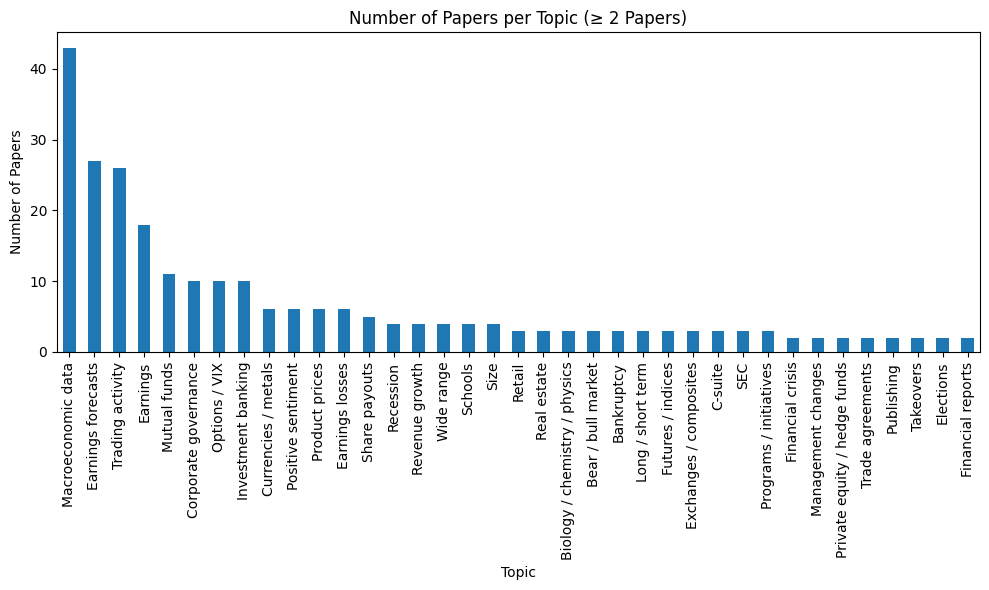

In [12]:
# Count unique papers per topic
counts = (
    final
    .drop_duplicates(["topic", "paper_id"])
    .groupby("topic")["paper_id"]
    .nunique()
    .sort_values(ascending=False)
)

# remove NA topic
counts = counts[counts.index != "NA"]

# Keep only topics with more than 1 paper
counts = counts[counts > 1]

# Bar plot
plt.figure(figsize=(10, 6))
counts.plot(kind="bar")

plt.xlabel("Topic")
plt.ylabel("Number of Papers")
plt.title("Number of Papers per Topic (≥ 2 Papers)")

plt.tight_layout()
plt.show()


In [14]:
# save results to csv
final.to_csv(r"C:\Users\jonat\Lasso_paper\narratives_construction\_data\final_edges_topics.csv", index=False)